In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv("../.env")
pd.set_option('display.max_columns', None)

In [ ]:
bucket = os.getenv("AWS_BUCKET_NAME")
df = pd.read_parquet(f"s3://{bucket}/silver/mta_weather_merged.parquet")
print(f"Data loaded successfully! Shape: {df.shape}")

In [58]:
df.columns

Index(['transit_date', 'station_complex', 'borough', 'daily_ridership', 'name',
       'tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin',
       'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover',
       'preciptype', 'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir',
       'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation',
       'solarenergy', 'uvindex', 'severerisk', 'sunrise', 'sunset',
       'moonphase', 'conditions', 'description', 'icon', 'stations'],
      dtype='object')

In [45]:
df_daily = df.groupby('transit_date').agg({
    'daily_ridership': 'sum',
    'temp': 'mean',
    'precip': 'mean',
    'snow': 'mean'
}).sort_index()


In [46]:
df_daily.isnull().sum()

daily_ridership    0
temp               0
precip             0
snow               0
dtype: int64

In [47]:
# Check if any days are missing from the timeline
expected_range = pd.date_range(start=df_daily.index.min(), end=df_daily.index.max())
missing_days = expected_range.difference(df_daily.index)
print(f"Missing days in timeline: {len(missing_days)}")

Missing days in timeline: 0


In [48]:
# Stationary test (ADF (Augmented Dickey-Fuller) test)
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    for thres, adf_stat in result[4].items():
        print('\t%s: %.2f' % (thres, adf_stat))
    if result[1] <= 0.05:
        print("Conclusion: Data is stationary (p <= 0.05)")
    else:
        print("Conclusion: Data is non-stationary (p > 0.05). Differencing (d=1) is recommended.")

print("Testing Stationarity of Raw Ridership:")
check_stationarity(df_daily['daily_ridership'])

Testing Stationarity of Raw Ridership:
ADF Statistic: -3.7505
p-value: 0.0035
	1%: -3.45
	5%: -2.87
	10%: -2.57
Conclusion: Data is stationary (p <= 0.05)


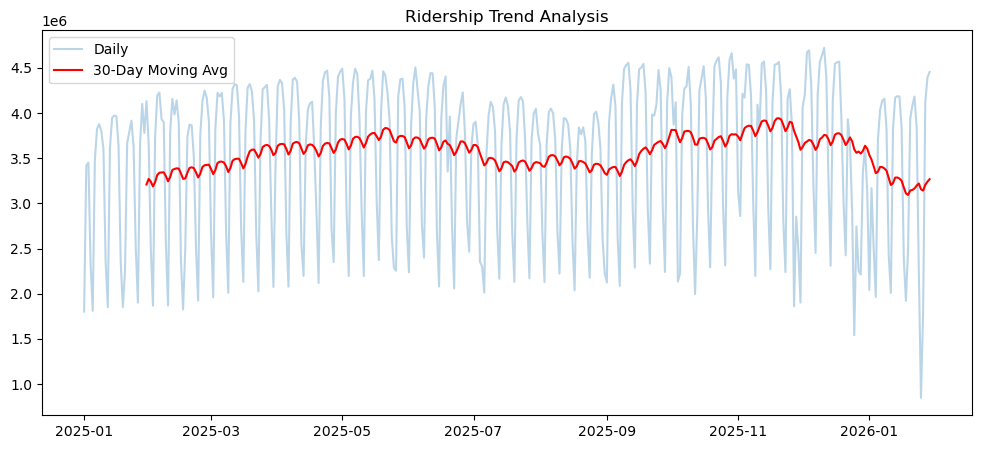

In [49]:
df_daily['daily_ridership'].rolling(30).mean()
plt.figure(figsize=(12, 5))
plt.plot(df_daily['daily_ridership'], label='Daily', alpha=0.3)
plt.plot(df_daily['daily_ridership'].rolling(30).mean(), label='30-Day Moving Avg', color='red')
plt.title("Ridership Trend Analysis")
plt.legend()
plt.show()

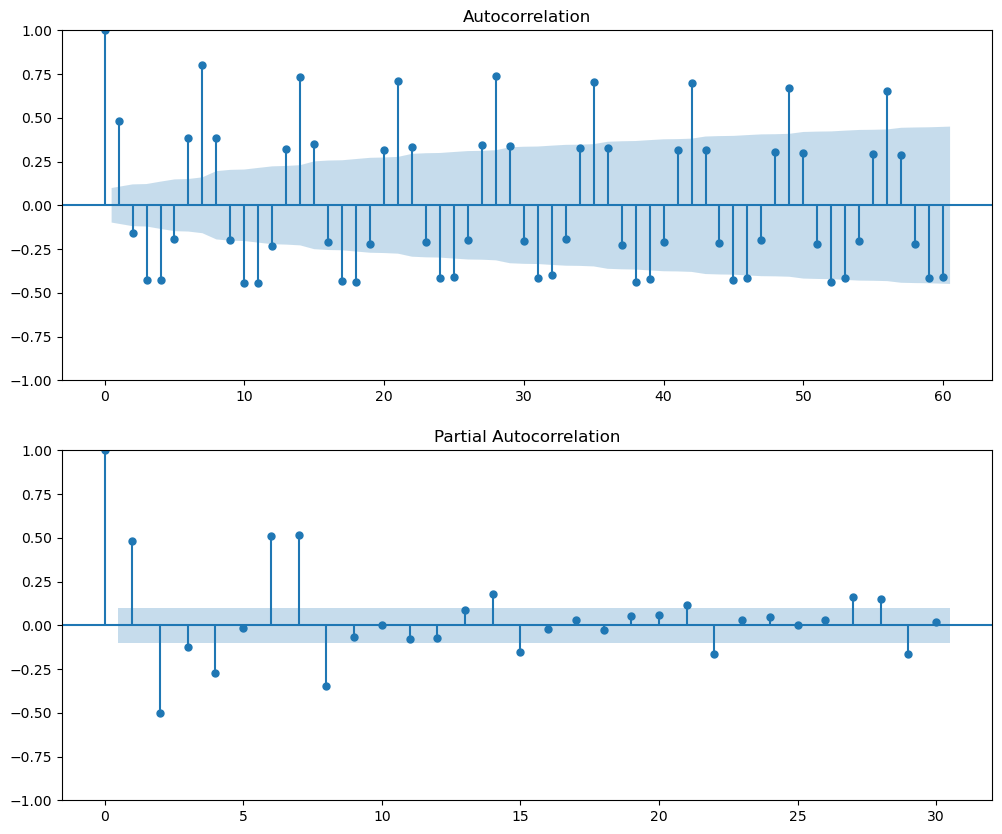

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plotting ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(df_daily['daily_ridership'], lags=60, ax=ax1)
plot_pacf(df_daily['daily_ridership'], lags=30, ax=ax2)
plt.show()

"The ACF plot shows significant spikes at 7-day intervals (7, 14, 21, 28), confirming strong weekly seasonality.

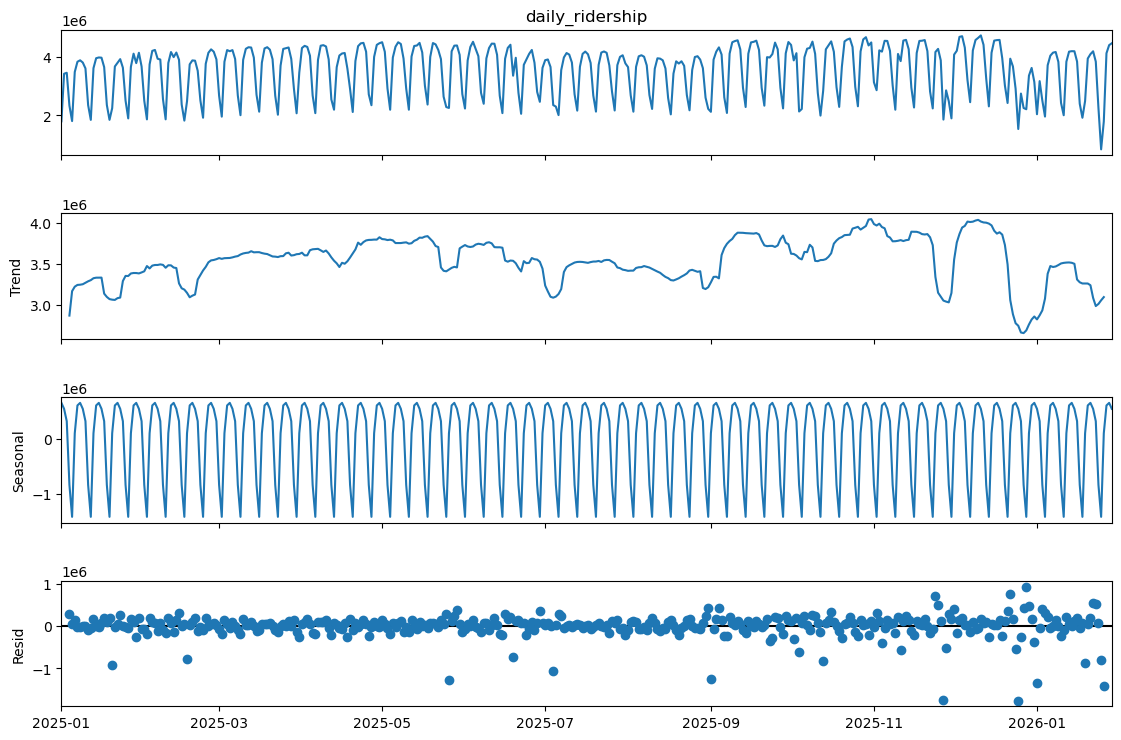

In [51]:
from statsmodels.tsa.seasonal import seasonal_decompose

# We use period=7 because the subway works on a weekly cycle
decomposition = seasonal_decompose(df_daily['daily_ridership'], model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

"This decomposition breaks ridership into three components: a steady Trend showing ridership fluctuations over months, a highly consistent 7-day Seasonality (the 'weekly heartbeat'), and Residuals. The residuals represent the 'noise'—the variations that the weekly cycle cannot explain, which we hypothesize are driven by weather and holidays."

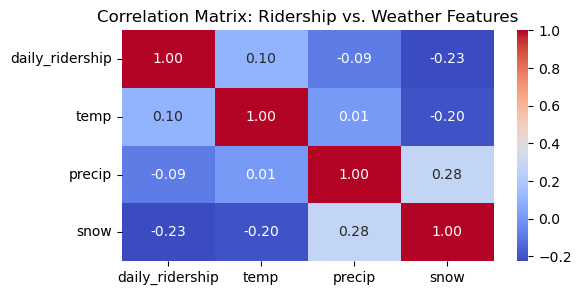

In [52]:
plt.figure(figsize=(6, 3))
sns.heatmap(df_daily.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Ridership vs. Weather Features")
plt.show()

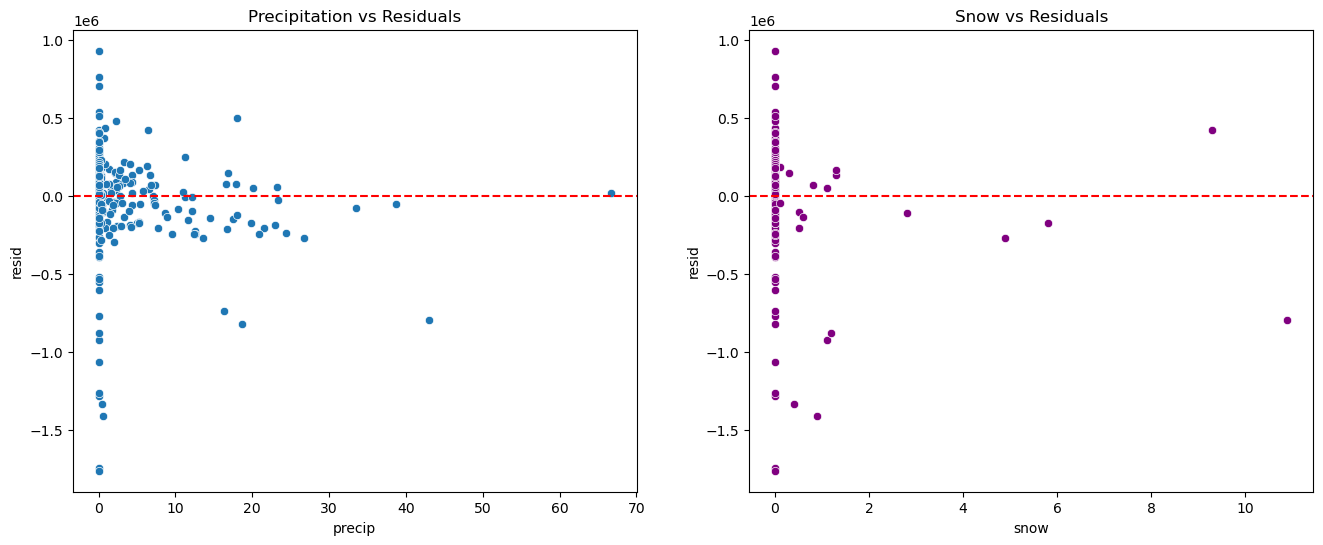

In [54]:
# We use the residuals from your earlier decomposition
df_resid = decomposition.resid

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Precip vs Residuals (You already have this, but keep it for comparison)
sns.scatterplot(x=df_daily['precip'], y=df_resid, ax=ax1)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title("Precipitation vs Residuals")

# Snow vs Residuals
sns.scatterplot(x=df_daily['snow'], y=df_resid, ax=ax2, color='purple')
ax2.axhline(0, color='red', linestyle='--')
ax2.set_title("Snow vs Residuals")
plt.show()

In [ ]:
# Compare snow vs snow_lag1 correlation with residuals
df_daily['snow_lag1'] = df_daily['snow'].shift(1)
df_resid_clean = df_resid.dropna()

snow_corr = df_daily['snow'].reindex(df_resid_clean.index).corr(df_resid_clean)
snow_lag1_corr = df_daily['snow_lag1'].reindex(df_resid_clean.index).corr(df_resid_clean)

print(f"Correlation — snow (same day) vs residuals:       {snow_corr:.3f}")
print(f"Correlation — snow_lag1 (yesterday) vs residuals: {snow_lag1_corr:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(x=df_daily['snow'].reindex(df_resid_clean.index), y=df_resid_clean, ax=ax1)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title(f"Today's Snow vs Residuals (r={snow_corr:.3f})")
ax1.set_xlabel("snow (cm)")

sns.scatterplot(x=df_daily['snow_lag1'].reindex(df_resid_clean.index), y=df_resid_clean,
                ax=ax2, color='purple')
ax2.axhline(0, color='red', linestyle='--')
ax2.set_title(f"Yesterday's Snow vs Residuals (r={snow_lag1_corr:.3f})")
ax2.set_xlabel("snow_lag1 (cm)")

plt.suptitle("Snow Lag Effect: Yesterday's Snow Better Predicts Today's Ridership Drop")
plt.tight_layout()
plt.show()

Yesterday's snow (`snow_lag1`) shows a stronger negative correlation with today's ridership than today's snow. This makes operational sense — when it snows heavily, the disruption (slush, service delays, unsafe footpaths) is felt most the following morning when commuters decide whether to travel. This justifies using `snow_lag1` rather than `snow` as the exogenous variable in SARIMAX.

The red line ($y=0$) represents our baseline expectation where ridership perfectly follows the weekly seasonal pattern. The downward "sink" in the scatter plots shows that as precipitation and snow increase, ridership falls significantly below this baseline, resulting in over-predictions. Snow shows the most severe impact, corroborated by its strong negative correlation of -0.23. These results confirm that a calendar-only model is insufficient and justify adding weather as exogenous features in a SARIMAX model.

<Axes: xlabel='day_of_week', ylabel='daily_ridership'>

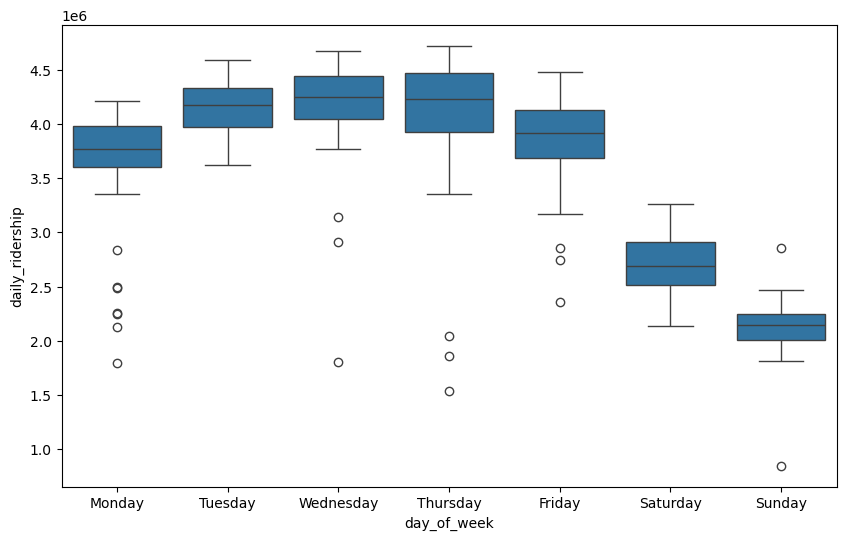

In [55]:
df_daily['day_of_week'] = df_daily.index.day_name()
plt.figure(figsize=(10,6))
sns.boxplot(data=df_daily, x='day_of_week', y='daily_ridership', 
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

In [57]:
# Look at the top 10 days where the model's 'expected' ridership was way higher than reality
print("Dates with the largest negative residuals (potential holidays/major events):")
print(df_resid.sort_values().head(10))

Dates with the largest negative residuals (potential holidays/major events):
transit_date
2025-12-25   -1.761304e+06
2025-11-27   -1.745777e+06
2026-01-26   -1.407949e+06
2026-01-01   -1.335515e+06
2025-05-26   -1.284022e+06
2025-09-01   -1.259759e+06
2025-07-04   -1.062765e+06
2025-01-20   -9.246284e+05
2026-01-19   -8.778322e+05
2025-10-13   -8.178729e+05
Name: resid, dtype: float64


An analysis of the largest negative residuals (where actual ridership was much lower than predicted) reveals that Federal Holidays are the primary cause of model error outside of weather events.

## Feature Selection for SARIMAX

**Target:** `daily_ridership` (city-wide sum)

**Exogenous features:** `temp`, `precip`, `snow_lag1`, `is_holiday`

- `temp` — direct weather comfort effect on whether people choose to travel
- `precip` — rain reduces ridership on the day it occurs
- `snow_lag1` — snow reduces ridership the *following* day (slush, unsafe conditions, disrupted schedules) more than the day it falls
- `is_holiday` — federal holidays cause the largest single-day ridership drops, larger than any weather event (Christmas: -1.76M, Thanksgiving: -1.75M)

SARIMAX handles weekly seasonality (period=7) internally via its seasonal AR/MA terms. Weather and holidays explain the residual variation the seasonal model alone cannot capture.